<a href="https://colab.research.google.com/github/SusanaBN30/Tareas/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ¿En qué gastamos los mexicanos? Un análisis de supervivencia y ahorro por nivel socioeconómico

---



In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('concentradohogar.csv')

total_filas = df.shape[0]
print(f"Total de viviendas/hogares analizados: {total_filas:,}")

Total de viviendas/hogares analizados: 91,414


In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Variables
variables_estratégicas = [
    'ubica_geo', 'est_socio', 'tam_loc','factor',        # Contexto y Peso estadístico
    'ing_cor', 'ingtrab', 'transfer',                    # Ingreso
    'gasto_mon', 'alimentos', 'vesti_calz', 'vivienda',  # Gastos
    'limpieza', 'salud', 'transporte', 'educa_espa',
    'personales', 'transf_gas',
    'pago_tarje', 'deudas'                               # Deudas
]

df_estudio = df[variables_estratégicas].copy()
df_estudio = df_estudio.fillna(0)

In [64]:
# Pasamos a datos mensuales porque nuestra base de datos es trimestral
cols_trimestrales = ['ing_cor', 'ingtrab', 'transfer', 'gasto_mon', 'alimentos', 'vesti_calz', 'vivienda', 'limpieza', 'salud', 'transporte', 'educa_espa', 'personales', 'transf_gas', 'pago_tarje', 'deudas']
for col in cols_trimestrales:
    df_estudio[f'{col}_mes'] = df_estudio[col] / 3

# Carga financiera total
df_estudio['carga_financiera_total_mes'] = df_estudio['pago_tarje_mes'] + df_estudio['deudas_mes']

In [65]:
# Calculamos el margen
df_estudio['margen_solvencia'] = df_estudio['ing_cor_mes'] - df_estudio['gasto_mon_mes']

# Identificamos hogares que gastan más de lo que ganan
hogares_deficit = df_estudio[df_estudio['margen_solvencia'] < 0].shape[0]
porcentaje_deficit = (hogares_deficit / len(df_estudio)) * 100

print(f"Hogares que gastan más de su ingreso mensual: {porcentaje_deficit:.2f}%")

Hogares que gastan más de su ingreso mensual: 15.35%


## Superivivencia

### Alimento (Engel)

In [66]:
# Engel
df_estudio['prop_alimentos'] = (df_estudio['alimentos_mes'] / df_estudio['ing_cor_mes']) * 100
df_estudio.replace([np.inf, -np.inf], np.nan, inplace=True)

# Solo nos quedamos con hogares que SÍ tienen ingresos
df_clean = df_estudio[df_estudio['ing_cor_mes'] > 0]
df_clean = df_clean.dropna(subset=['prop_alimentos', 'gasto_mon_mes'])

# Verificación
print(f"Son {len(df_estudio)} hogares válidos.")

Son 91414 hogares válidos.


In [68]:
# Deuda
df_clean['deuda'] = (df_clean['carga_financiera_total_mes'] / df_clean['ing_cor_mes']) * 100

In [69]:
# Agrupamos por estrato para ver ingresos vs gastos
tabla_est = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Ingreso_Promedio_Mensual': (x['ing_cor'] / 3).mean(),
        'Gasto_Alimentos_Porcentaje': np.average(x['prop_alimentos'], weights=x['factor']),
        'Gasto_Deuda_Porcentaje': np.average(x['deuda'], weights=x['factor'])
    })
).reset_index()

# Sumamos comida + deuda para ver el total comprometido
tabla_est['Total_Comprometido_Pct'] = tabla_est['Gasto_Alimentos_Porcentaje'] + tabla_est['Gasto_Deuda_Porcentaje']

# Calculamos cuánto queda libre para renta, luz, salud, etc.
tabla_est['Ingreso_Libre_Pct'] = 100 - tabla_est['Total_Comprometido_Pct']

print("TABLA DE IMPACTO ESTRATÉGICO")
display(tabla_est)

TABLA DE IMPACTO ESTRATÉGICO


/tmp/ipykernel_5522/2755240939.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_est = df_clean.groupby('est_socio').apply(


,est_socio,Ingreso_Promedio_Mensual,Gasto_Alimentos_Porcentaje,Gasto_Deuda_Porcentaje,Total_Comprometido_Pct,Ingreso_Libre_Pct
0,1,15900.786213,38.458976,0.801711,39.260687,60.739313
1,2,21572.348764,31.870424,1.290583,33.161008,66.838992
2,3,28982.261681,27.365492,1.848050,29.213542,70.786458
3,4,46645.610186,22.831912,4.414312,27.246224,72.753776


<Figure size 1200x700 with 0 Axes>

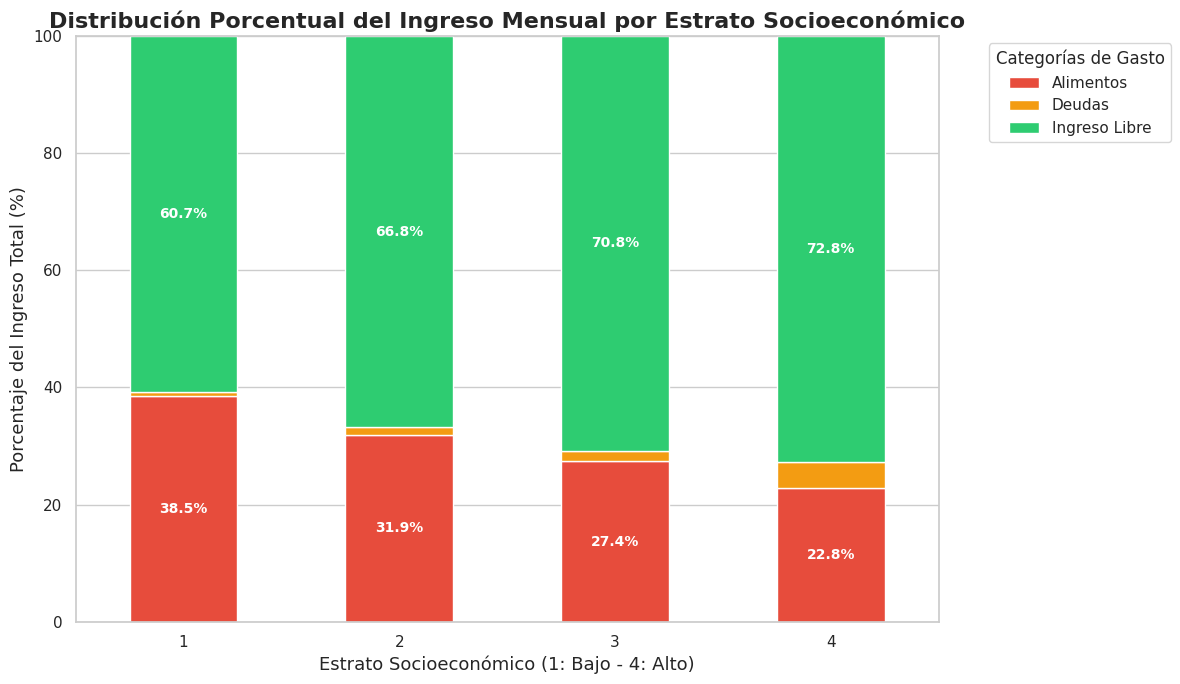

In [70]:
df_plot = tabla_est.melt(id_vars='est_socio',
                          value_vars=['Gasto_Alimentos_Porcentaje', 'Gasto_Deuda_Porcentaje', 'Ingreso_Libre_Pct'],
                          var_name='Categoría de Gasto',
                          value_name='Porcentaje')

mapa_nombres = {
    'Gasto_Alimentos_Porcentaje': 'Alimentos y Bebidas',
    'Gasto_Deuda_Porcentaje': 'Carga Financiera (Deudas)',
    'Ingreso_Libre_Pct': 'Ingreso Disponible para Otros Gastos'
}
df_plot['Categoría de Gasto'] = df_plot['Categoría de Gasto'].map(mapa_nombres)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

colores = ["#e74c3c", "#f39c12", "#2ecc71"]
sns.set_palette(sns.color_palette(colores))

df_plot_pandas = tabla_est.set_index('est_socio')[['Gasto_Alimentos_Porcentaje', 'Gasto_Deuda_Porcentaje', 'Ingreso_Libre_Pct']]
df_plot_pandas.columns = ['Alimentos', 'Deudas', 'Ingreso Libre']

ax = df_plot_pandas.plot(kind='bar', stacked=True, color=colores, figsize=(12, 7), rot=0)

plt.title('Distribución Porcentual del Ingreso Mensual por Estrato Socioeconómico', fontsize=16, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso Total (%)', fontsize=13)
plt.xlabel('Estrato Socioeconómico (1: Bajo - 4: Alto)', fontsize=13)

plt.ylim(0, 100)

plt.legend(title='Categorías de Gasto', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)


for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Alimento, vivienda y transporte

In [72]:
# Gastos que no se pueden evitar
df_clean['supervivencia'] = ((df_clean['alimentos_mes'] + df_clean['vivienda_mes'] + df_clean['transporte_mes']) / df_clean['ing_cor_mes']) * 100

In [73]:
tabla_supervivencia = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Alimentos_%': np.average(x['prop_alimentos'], weights=x['factor']),
        'Vivienda_%': np.average((x['vivienda_mes']/x['ing_cor_mes'])*100, weights=x['factor']),
        'Transporte_%': np.average((x['transporte_mes']/x['ing_cor_mes'])*100, weights=x['factor']),
        'Total_Supervivencia_%': np.average(x['supervivencia'], weights=x['factor'])
    })
).reset_index()

print("ANÁLISIS DE SUPERVIVENCIA POR ESTRATO")
display(tabla_supervivencia)

ANÁLISIS DE SUPERVIVENCIA POR ESTRATO


/tmp/ipykernel_5522/443131878.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_supervivencia = df_clean.groupby('est_socio').apply(


,est_socio,Alimentos_%,Vivienda_%,Transporte_%,Total_Supervivencia_%
0,1,38.458976,4.626032,11.625607,54.710615
1,2,31.870424,6.512416,12.544365,50.927206
2,3,27.365492,7.650790,12.949060,47.965342
3,4,22.831912,9.605443,12.736651,45.174006


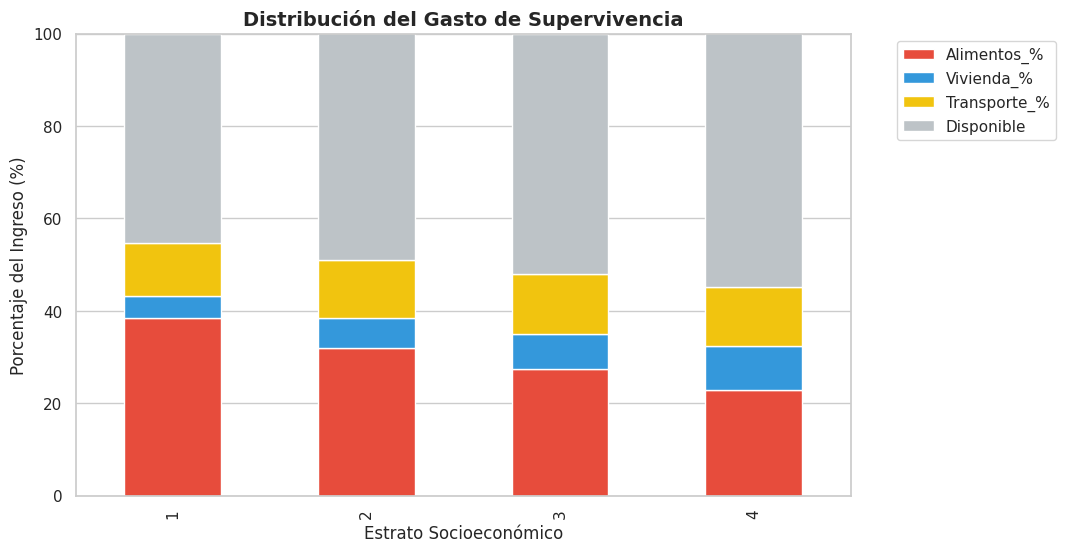

In [74]:
df_surv_plot = tabla_supervivencia.copy()
df_surv_plot['Disponible'] = 100 - df_surv_plot['Total_Supervivencia_%']

ax = df_surv_plot.plot(kind='bar', x='est_socio',
                       y=['Alimentos_%', 'Vivienda_%', 'Transporte_%', 'Disponible'],
                       stacked=True, figsize=(10,6),
                       color=['#e74c3c', '#3498db', '#f1c40f', '#bdc3c7'])

plt.title('Distribución del Gasto de Supervivencia', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Estrato Socioeconómico')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.show()

## Equipamiento y Mantenimiento

In [75]:
# Limpieza del hogar, muebles, utensilios, etc
df_clean['equipamiento'] = (df_clean['limpieza_mes'] / df_clean['ing_cor_mes']) * 100

In [76]:
tabla_mantenimiento = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Gasto_Mensual_Promedio ($)': x['limpieza_mes'].mean(),
        'Porcentaje_del_Ingreso (%)': np.average(x['equipamiento'], weights=x['factor']),
    })
).reset_index()

print("TABLA: BLOQUE DE EQUIPAMIENTO Y MANTENIMIENTO DEL HOGAR")
display(tabla_mantenimiento)

TABLA: BLOQUE DE EQUIPAMIENTO Y MANTENIMIENTO DEL HOGAR


/tmp/ipykernel_5522/276836067.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_mantenimiento = df_clean.groupby('est_socio').apply(


,est_socio,Gasto_Mensual_Promedio ($),Porcentaje_del_Ingreso (%)
0,1,650.096377,5.222790
1,2,821.362730,4.348509
2,3,1080.084715,3.869728
3,4,1944.357959,4.158333


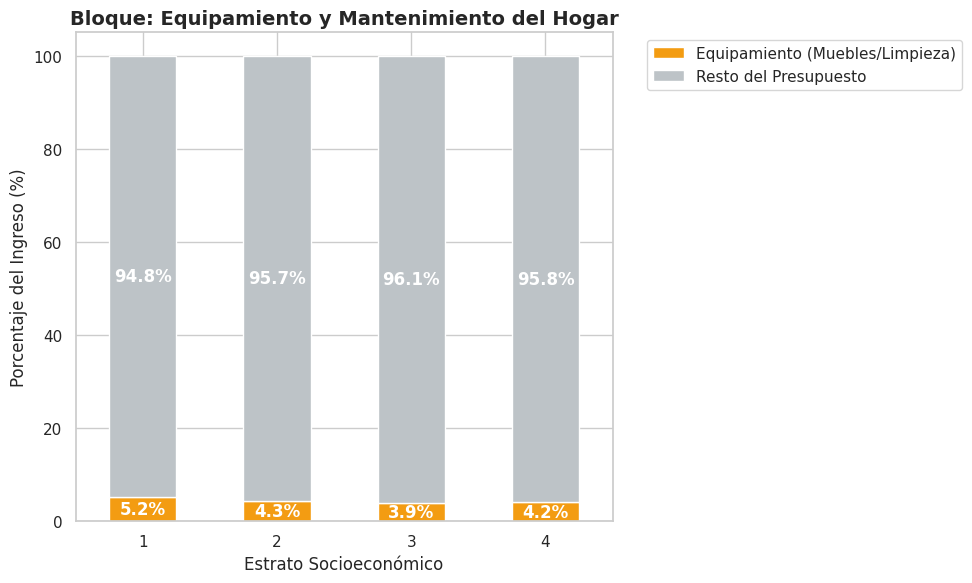

In [77]:
df_mante_plot = tabla_mantenimiento.copy()
df_mante_plot['Resto_del_Ingreso'] = 100 - df_mante_plot['Porcentaje_del_Ingreso (%)']

ax = df_mante_plot.plot(kind='bar', x='est_socio',
                        y=['Porcentaje_del_Ingreso (%)', 'Resto_del_Ingreso'],
                        stacked=True, figsize=(10,6),
                        color=['#f39c12', '#bdc3c7'],
                        rot=0)

plt.title('Bloque: Equipamiento y Mantenimiento del Hogar', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Estrato Socioeconómico')
plt.legend(['Equipamiento (Muebles/Limpieza)', 'Resto del Presupuesto'],
           bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Bienestar



In [78]:
df_clean['bienestar'] = ((df_clean['salud_mes'] + df_clean['educa_espa_mes']) / df_clean['ing_cor_mes']) * 100

In [79]:
tabla_bienestar = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Bienestar_% (Salud/Edu)': np.average(x['bienestar'], weights=x['factor']),
    })
).reset_index()

print("CAPACIDAD DE EXCEDENTE Y DESARROLLO")
display(tabla_bienestar)

CAPACIDAD DE EXCEDENTE Y DESARROLLO


/tmp/ipykernel_5522/1747424362.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_bienestar = df_clean.groupby('est_socio').apply(


,est_socio,Bienestar_% (Salud/Edu)
0,1,7.348642
1,2,7.422196
2,3,7.530088
3,4,9.677961


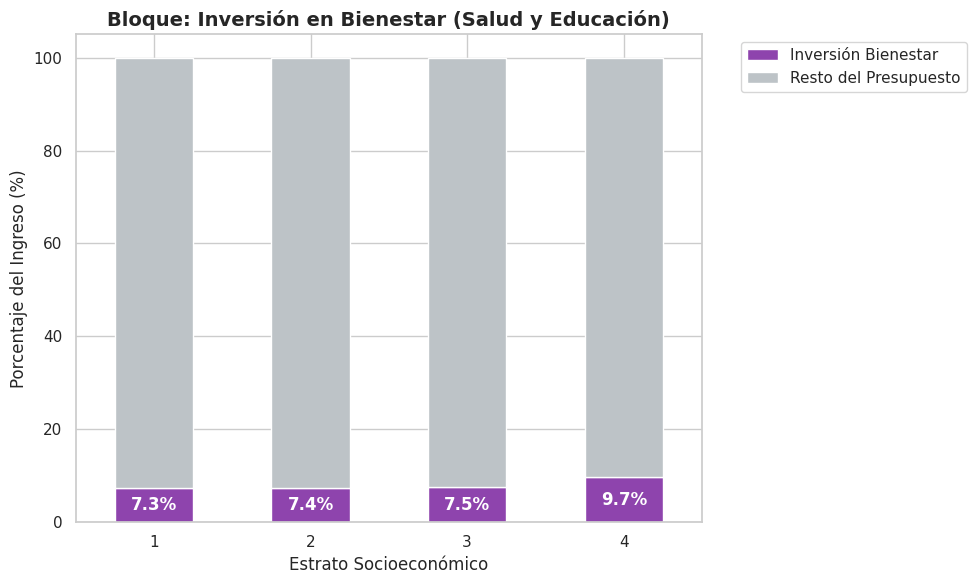

In [80]:
df_bien_plot = tabla_bienestar.copy()
df_bien_plot['Resto_del_Presupuesto'] = 100 - df_bien_plot['Bienestar_% (Salud/Edu)']

ax = df_bien_plot.plot(kind='bar', x='est_socio',
                        y=['Bienestar_% (Salud/Edu)', 'Resto_del_Presupuesto'],
                        stacked=True, figsize=(10,6),
                        color=['#8e44ad', '#bdc3c7'],
                        rot=0)

plt.title('Bloque: Inversión en Bienestar (Salud y Educación)', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Estrato Socioeconómico')
plt.legend(['Inversión Bienestar', 'Resto del Presupuesto'],
           bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    if c == ax.containers[0]:
        labels = [f'{v.get_height():.1f}%' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Otros Gastos

In [81]:
df_clean['otros_consumos'] = ((df_clean['vesti_calz_mes'] + (df_clean['personales_mes'] / 3) + (df_clean['transf_gas_mes'] / 3)) / df_clean['ing_cor_mes']) * 100

In [82]:
tabla_otros_gastos = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Gasto_Mensual_Promedio ($)': (x['vesti_calz_mes'] + x['personales_mes'] + x['transf_gas_mes']).mean(),
        'Porcentaje_del_Ingreso (%)': np.average(x['otros_consumos'], weights=x['factor'])
    })
).reset_index()

print("TABLA: BLOQUE DE CONSUMO PERSONAL Y OTROS GASTOS")
display(tabla_otros_gastos)

TABLA: BLOQUE DE CONSUMO PERSONAL Y OTROS GASTOS


/tmp/ipykernel_5522/1948761650.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_otros_gastos = df_clean.groupby('est_socio').apply(


,est_socio,Gasto_Mensual_Promedio ($),Porcentaje_del_Ingreso (%)
0,1,1491.448612,5.655914
1,2,1884.838434,4.823979
2,3,2576.669828,4.668885
3,4,3910.925188,4.349692


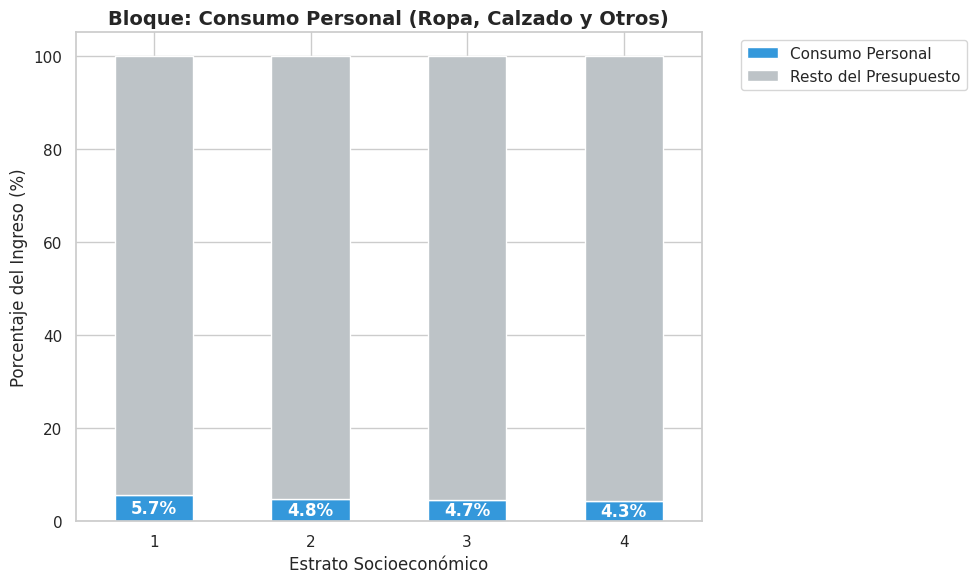

In [83]:
df_otros_plot = tabla_otros_gastos.copy()
df_otros_plot['Resto_del_Presupuesto'] = 100 - df_otros_plot['Porcentaje_del_Ingreso (%)']

ax = df_otros_plot.plot(kind='bar', x='est_socio',
                         y=['Porcentaje_del_Ingreso (%)', 'Resto_del_Presupuesto'],
                         stacked=True, figsize=(10,6),
                         color=['#3498db', '#bdc3c7'],
                         rot=0)

plt.title('Bloque: Consumo Personal (Ropa, Calzado y Otros)', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Estrato Socioeconómico')
plt.legend(['Consumo Personal', 'Resto del Presupuesto'],
           bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    if c == ax.containers[0]:
        labels = [f'{v.get_height():.1f}%' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Deuda y Carga Financiera

In [84]:
tabla_deuda = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Carga_Financiera_Total_%': np.average(x['deuda'], weights=x['factor']),
        'Ingreso_Promedio': x['ing_cor_mes'].mean()
    })
).reset_index()

print("ESTRUCTURA DE ENDEUDAMIENTO")
display(tabla_deuda)

ESTRUCTURA DE ENDEUDAMIENTO


/tmp/ipykernel_5522/1506582909.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_deuda = df_clean.groupby('est_socio').apply(


,est_socio,Carga_Financiera_Total_%,Ingreso_Promedio
0,1,0.801711,15900.786213
1,2,1.290583,21572.348764
2,3,1.848050,28982.261681
3,4,4.414312,46645.610186


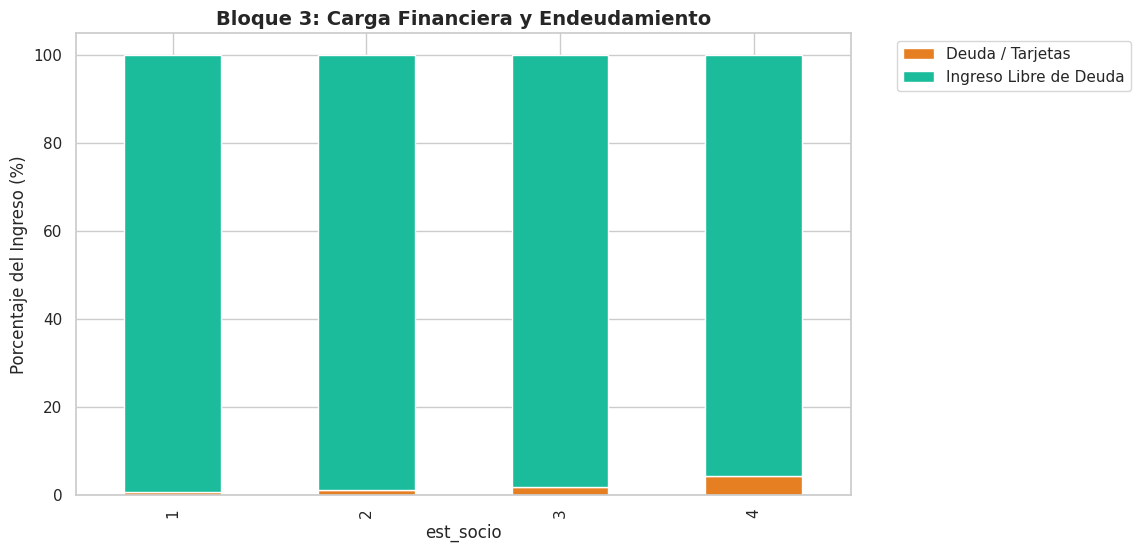

In [85]:
df_deuda_plot = tabla_deuda.copy()
df_deuda_plot['Ingreso_Neto_Disponible'] = 100 - df_deuda_plot['Carga_Financiera_Total_%']

ax = df_deuda_plot.plot(kind='bar', x='est_socio',
                        y=['Carga_Financiera_Total_%', 'Ingreso_Neto_Disponible'],
                        stacked=True, figsize=(10,6),
                        color=['#e67e22', '#1abc9c'])

plt.title('Bloque 3: Carga Financiera y Endeudamiento', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.legend(['Deuda / Tarjetas', 'Ingreso Libre de Deuda'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Excedente

In [86]:
# Excedente real
df_clean['excedente_mensual'] = df_clean['ing_cor_mes'] - df_clean['gasto_mon_mes']
df_clean['excedente'] = (df_clean['excedente_mensual'] / df_clean['ing_cor_mes']) * 100

In [87]:
tabla_resiliencia = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Excedente_Mensual_Promedio ($)': x['excedente_mensual'].mean(),
        'Porcentaje_de_Resiliencia (%)': np.average(x['excedente'], weights=x['factor'])
    })
).reset_index()

print("TABLA: BLOQUE DE RESILIENCIA (EXCEDENTE Y AHORRO)")
display(tabla_resiliencia)

TABLA: BLOQUE DE RESILIENCIA (EXCEDENTE Y AHORRO)


/tmp/ipykernel_5522/3207356137.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_resiliencia = df_clean.groupby('est_socio').apply(


,est_socio,Excedente_Mensual_Promedio ($),Porcentaje_de_Resiliencia (%)
0,1,5954.624932,22.097282
1,2,8619.784007,27.756637
2,3,11662.775683,31.544859
3,4,19335.516635,32.357567


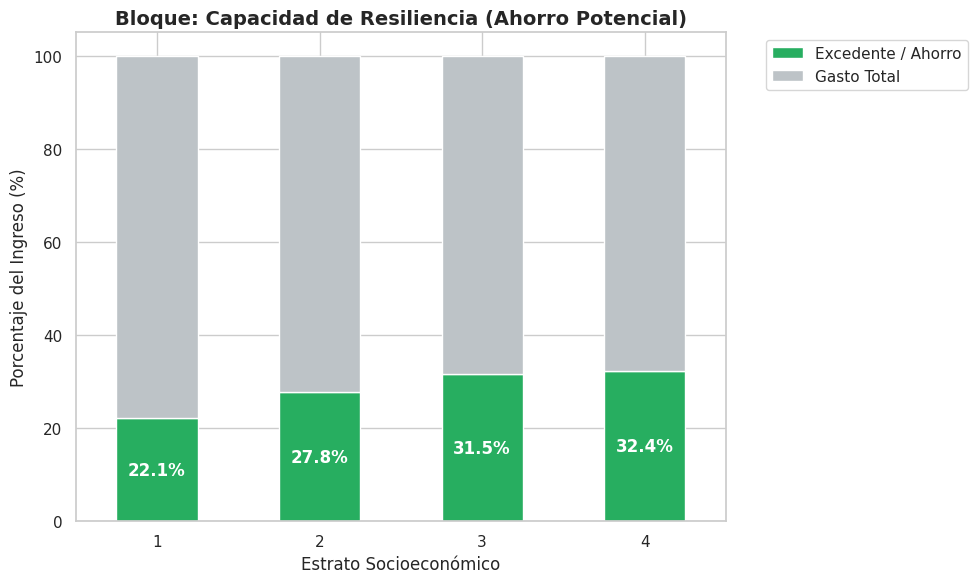

In [88]:
df_res_plot = tabla_resiliencia.copy()
df_res_plot['Ingreso_Comprometido'] = 100 - df_res_plot['Porcentaje_de_Resiliencia (%)']

ax = df_res_plot.plot(kind='bar', x='est_socio',
                       y=['Porcentaje_de_Resiliencia (%)', 'Ingreso_Comprometido'],
                       stacked=True, figsize=(10,6),
                       color=['#27ae60', '#bdc3c7'],
                       rot=0)

plt.title('Bloque: Capacidad de Resiliencia (Ahorro Potencial)', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Estrato Socioeconómico')
plt.legend(['Excedente / Ahorro', 'Gasto Total'],
           bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    if c == ax.containers[0]:
        labels = [f'{v.get_height():.1f}%' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis Total

In [90]:
tabla_analisis_final = df_clean.groupby('est_socio').apply(
    lambda x: pd.Series({
        'Supervivencia': np.average(x['supervivencia'], weights=x['factor']),
        'Mantenimiento': np.average(x['equipamiento'], weights=x['factor']),
        'Bienestar': np.average(x['bienestar'], weights=x['factor']),
        'Otros Gastos': np.average(x['otros_consumos'], weights=x['factor']),
        'Resiliencia (Ahorro)': np.average(x['excedente'], weights=x['factor'])
    })
).reset_index()

print("TABLA: ANÁLISIS FINAL)")
display(tabla_analisis_final)

TABLA: ANÁLISIS FINAL)


/tmp/ipykernel_5522/2939177907.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_analisis_final = df_clean.groupby('est_socio').apply(


,est_socio,Supervivencia,Mantenimiento,Bienestar,Otros Gastos,Resiliencia (Ahorro)
0,1,54.710615,5.222790,7.348642,5.655914,22.097282
1,2,50.927206,4.348509,7.422196,4.823979,27.756637
2,3,47.965342,3.869728,7.530088,4.668885,31.544859
3,4,45.174006,4.158333,9.677961,4.349692,32.357567


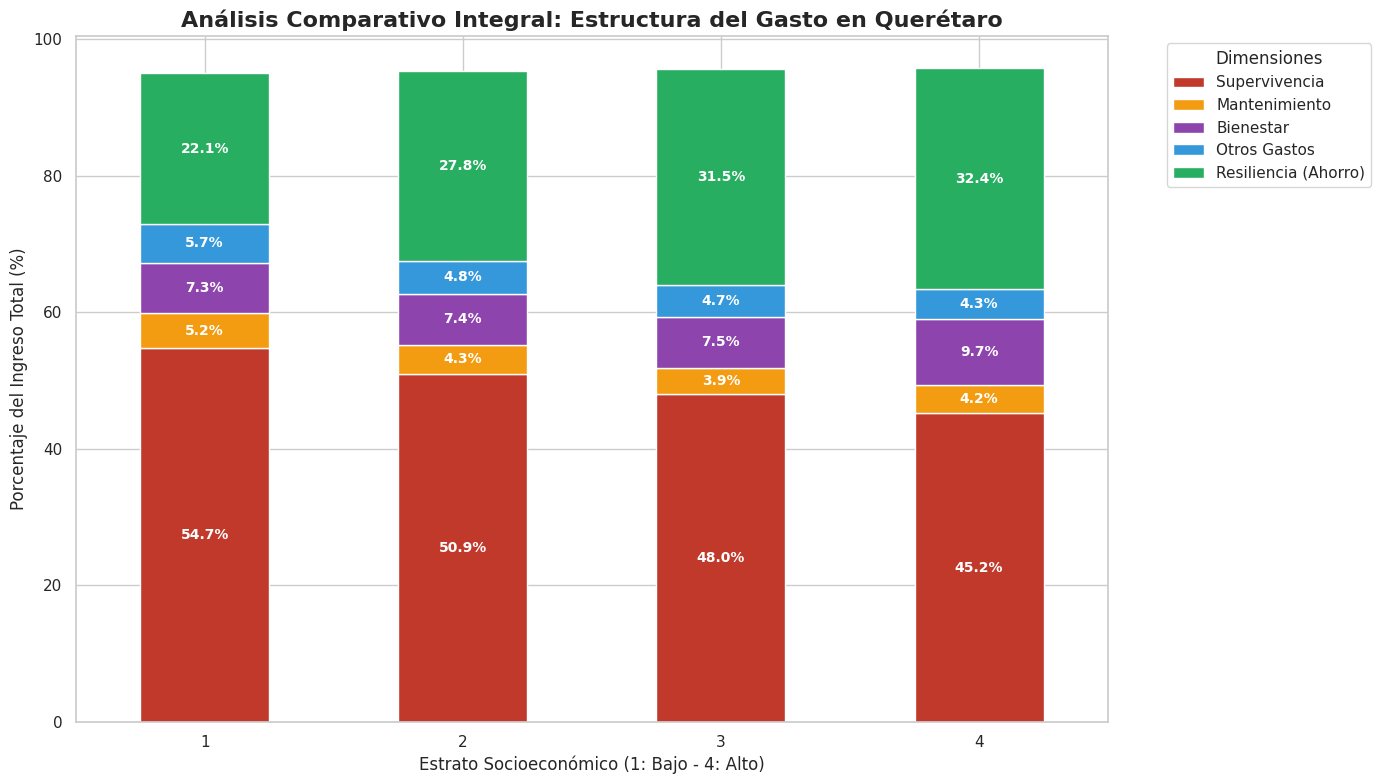

In [91]:
colors = ['#c0392b', '#f39c12', '#8e44ad', '#3498db', '#27ae60']
ax = tabla_analisis_final.plot(kind='bar', x='est_socio', stacked=True,
                               figsize=(14, 8), color=colors, rot=0)

plt.title('Análisis Comparativo Integral: Estructura del Gasto en Querétaro', fontsize=16, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso Total (%)')
plt.xlabel('Estrato Socioeconómico (1: Bajo - 4: Alto)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Dimensiones')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Análisis por tamaño de localidad

In [93]:
mapping_tam = {
    '1': 'Urbano (>100k)',
    '2': 'Semi-urbano (15k-100k)',
    '3': 'Semi-rural (2.5k-15k)',
    '4': 'Rural (<2.5k)'
}
df_clean['desc_tam_loc'] = df_clean['tam_loc'].astype(str).map(mapping_tam)

tabla_geografica = df_clean.groupby('desc_tam_loc').apply(
    lambda x: pd.Series({
        'Supervivencia (%)': np.average(x['supervivencia'], weights=x['factor']),
        'Resiliencia (%)': np.average(x['excedente'], weights=x['factor']),
        'Ingreso_Promedio': x['ing_cor_mes'].mean()
    })
).reindex(['Urbano (>100k)', 'Semi-urbano (15k-100k)', 'Semi-rural (2.5k-15k)', 'Rural (<2.5k)']).reset_index()

display(tabla_geografica)

/tmp/ipykernel_5522/1114891870.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_geografica = df_clean.groupby('desc_tam_loc').apply(


,desc_tam_loc,Supervivencia (%),Resiliencia (%),Ingreso_Promedio
0,Urbano (>100k),47.939536,31.823421,31269.574287
1,Semi-urbano (15k-100k),49.812375,28.035185,24635.325795
2,Semi-rural (2.5k-15k),51.131225,27.031520,21232.580231
3,Rural (<2.5k),54.350034,21.493836,17927.357021


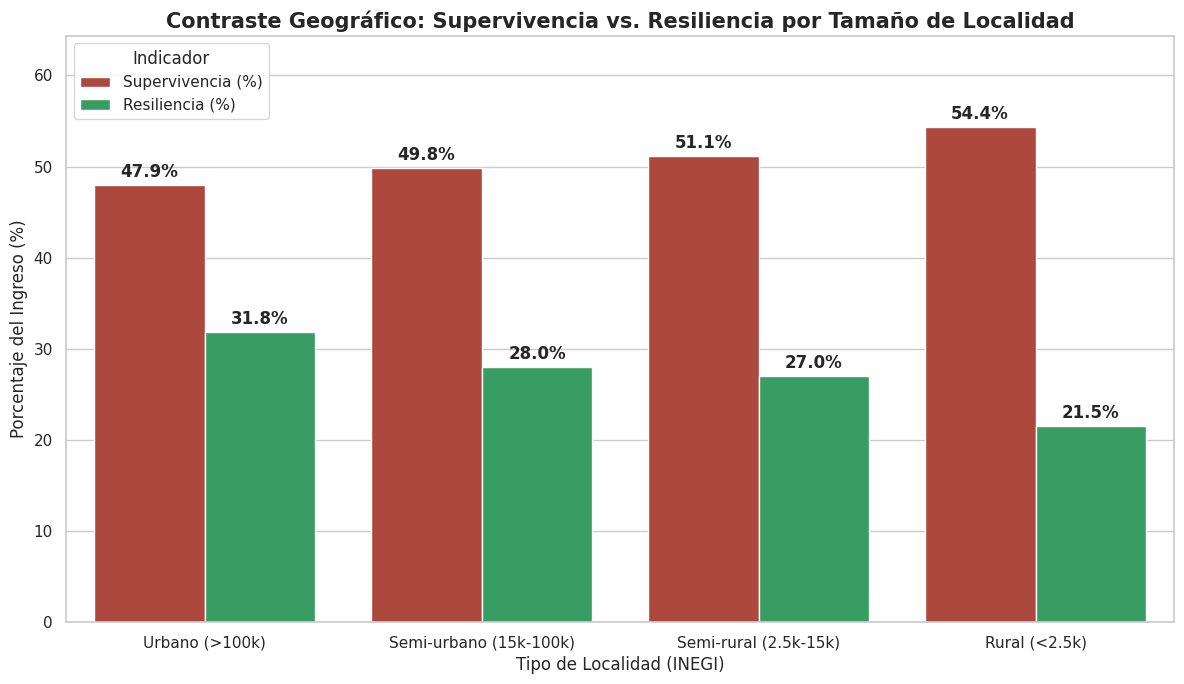

In [95]:
tabla_geo_melt = tabla_geografica.melt(id_vars='desc_tam_loc',
                                       value_vars=['Supervivencia (%)', 'Resiliencia (%)'],
                                       var_name='Dimensión', value_name='Porcentaje')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=tabla_geo_melt, x='desc_tam_loc', y='Porcentaje', hue='Dimensión',
                 palette=['#c0392b', '#27ae60'])

plt.title('Contraste Geográfico: Supervivencia vs. Resiliencia por Tamaño de Localidad',
          fontsize=15, fontweight='bold')
plt.ylabel('Porcentaje del Ingreso (%)')
plt.xlabel('Tipo de Localidad (INEGI)')
plt.ylim(0, tabla_geo_melt['Porcentaje'].max() + 10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')

plt.legend(title='Indicador')
plt.tight_layout()
plt.show()